**Πριν ξεκινήσεις να τρέχεις τον κώδικα**

Κάνε κλικ στο <kbd>Runtime</kbd> στην κορυφή της σελίδας, και στις επιλογές <kbd>change runtime type</kbd> ή <kbd>runtime options</kbd>. Εκεί επίλεξε ένα κουτάκι που λέει <kbd>(T4) GPU</kbd>.

**Πώς χρησιμοποιείς αυτό το αρχείο;**

Αυτό το αρχείο είναι ένα *jupyter notebook*, που αποτελείται από κελιά κειμένου (όπως αυτό) και κελιά κώδικα (όπως το παραπάνω). Μπορείς να τρέξεις τα κελιά κώδικα με <kbd>shift</kbd> + <kbd>enter</kbd>. Πριν προχωρήσεις, είναι σημαντικό να τρέξεις το παραπάνω κελί, ώστε o υπολογιστής να μπορεί να εισάγει όλες τις απαραίτητες συναρτήσεις.


In [2]:
import pip

import numpy as np
import os
from glob import glob
import torch
from PIL import Image
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import torch.nn.functional as F

%pip install medmnist

%pip install SimpleITK
import SimpleITK as sitk


!git clone https://github.com/NicosStarreveld/WorkshopCNNs.git

fatal: destination path 'WorkshopCNNs' already exists and is not an empty directory.


# Τα μαθηματικά πίσω από την ΤΝ - Εφαρμογή: ιατρικά δεδομένα

Τα νευρωνικά δίκτυα (CNNs) μπορούν να χρησιμοποιηθούν για την αυτόματη ερμηνεία εικόνων. Οι υπολογιστές είναι μάλιστα καλύτεροι σε ορισμένες εργασίες ανάλυσης εικόνας από τους ανθρώπους, επειδή οι άνθρωποι έχουν μικρή διάρκεια συγκέντρωσης. Σ' αυτό το εργαστήριο θα ρίξουμε μια ματιά στο πώς ένας υπολογιστής μπορεί να ερμηνεύει εικόνες. Θα εργαστούμε με ένα (δημόσιο) ιατρικό σύνολο δεδομένων και θα εκπαιδεύσουμε το δικό μας δίκτυο που μπορεί να ξεχωρίζει μεταξύ εικόνων δοντιών με και χωρίς απονεύρωση.

### Ψηφιακές εικόνες

Ο υπολογιστής βλέπει μια εικόνα ως έναν μεγάλη πίνακα με αριθμούς, κάθε στοιχείο του πίνακα (γνωστότερο ως *pixel*) περιέχει την τοπική ένταση της εικόνας. Στην περίπτωση μιας έγχρωμης εικόνας, πρόκειται για τρεις πίνακες τον έναν πάνω στον άλλο, που αντιπροσωπεύουν αντίστοιχα το κόκκινο, το μπλε και το πράσινο κανάλι. Στην περίπτωση μιας ασπρόμαυρης εικόνας, η ψηφιακή εικόνα είναι ένας μοναδικός πίνακας με εντάσεις.

In [3]:
#definieert twee functies die je later kan gebruiken om de images te openen en te visualiseren
def open_img(path):
    if path.endswith('.png'):
        return np.array(Image.open(path).convert('L'))
    elif path.endswith('.mhd'):
        return sitk.GetArrayFromImage(sitk.ReadImage(path))[32,:,:] # return 1 slice of the image

def visualize(img, clim=[-300,450]):
    plt.imshow(img, cmap='gray', clim=clim)
    plt.axis('off')
    plt.show()

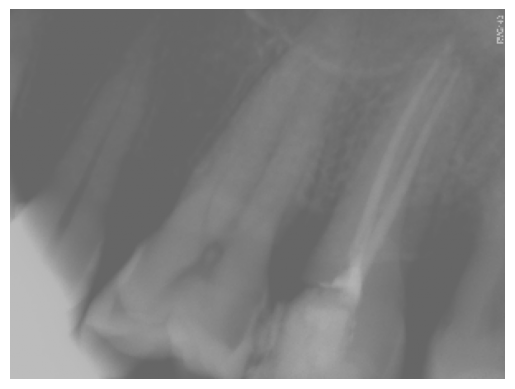

In [4]:
# inladen van beeld van de ribbenkast
# definieer pad naar beeld
# img_path = 'data/ribs/VinDr_RibCXR_train_000.png'
img_path = 'WorkshopCNNs/Xrays_with/167.png'
img = open_img(img_path)
# visualiseer beeld
visualize(img)

## Convolutional Neural Network

Οι εν λόγω συνελικτικές λειτουργίες αποτελούν τη βάση ενός λεγόμενου συνελικτικού νευρωνικού δικτύου. Στην ουσία, πρόκειται για ένα νευρωνικό δίκτυο που μπορεί να χρησιμοποιηθεί για διάφορες εργασίες υπολογιστικής όρασης, όπως η ταξινόμηση εικόνων, η ανίχνευση αντικειμένων ή ακόμη και ο προσδιορισμός των ακριβών ορίων ενός αντικειμένου σε μια εικόνα. Τα συνελικτικά νευρωνικά δίκτυα αποτελούνται από μια στοίβα συνελικτικών επιπέδων. Εφαρμόζοντας συνεχώς συνελικτικές λειτουργίες μέσα σε μια «στοίβα», ο υπολογιστής μπορεί να εξετάζει μια ολοένα και μεγαλύτερη τοπική περιοχή γύρω από κάθε εικονοστοιχείο (perceptive field). Οι πυρήνες σε όλες αυτές τις συνελικές λειτουργίες δεν καθορίζονται από ανθρώπους, αλλά προσδιορίζονται κατά τη διάρκεια της εκπαίδευσης αυτού του δικτύου. Στην υπόλοιπη ενότητα αυτού του notebook θα δείξουμε ένα μικρό παράδειγμα του πώς λειτουργεί αυτό και πώς μπορούμε να αξιολογήσουμε πόσο καλό είναι το δίκτυο στη συγκεκριμένη εργασία του.

### Τεχνικό βήμα  - ο κώδικας εδώ δεν έχει κάτι ιδιαίτερα ενδιαφέρον για την εφαρμογή

In [5]:
# Φτιάχνω τις εικόνες σε μορφή ώστε να τις διαβάσει το CNN. Αυτό είναι ένα
# τεχνικό βήμα ώστε να μπορεί το πρόγραμμα να επεξεργαστεί τις εικόνες

import cv2
from sklearn.model_selection import train_test_split

images = []
labels = []
orig_images = []

for filename in os.listdir("WorkshopCNNs/Xrays_with"):
  if 'ipynb' in filename: continue
  orig = cv2.imread(f"WorkshopCNNs/Xrays_with/{filename}", cv2.IMREAD_GRAYSCALE)
  img = cv2.resize(orig, (128, 128))
  img = img.astype(np.uint8)

  orig_images.append(orig)
  images.append(img)
  labels.append([1])

for filename in os.listdir("WorkshopCNNs/Xrays_without"):
  if 'ipynb' in filename: continue
  orig = cv2.imread(f"WorkshopCNNs/Xrays_without/{filename}", cv2.IMREAD_GRAYSCALE)
  img = cv2.resize(orig, (128, 128))
  img = img.astype(np.uint8)

  orig_images.append(orig)
  images.append(img)
  labels.append([0])

images = np.array(images)
labels = np.array(labels)
orig_images = np.array(orig_images, dtype=object)

# Split resized images AND original images together
X_train, X_temp, X_train_orig, X_temp_orig, y_train, y_temp = train_test_split( images, orig_images, labels, test_size=0.3 )
X_val, X_test, X_val_orig, X_test_orig, y_val, y_test = train_test_split( X_temp, X_temp_orig, y_temp, test_size=0.5 )

# Opslaan in MedMNIST-formaat
np.savez("teethmnist.npz",
         train_images=X_train, train_labels=y_train, train_orig=X_train_orig,
         val_images=X_val, val_labels=y_val, val_orig=X_val_orig,
         test_images=X_test, test_labels=y_test, test_orig=X_test_orig)

### Τεχνικό βήμα 2 - ο κώδικας εδώ δεν έχει κάτι ιδιαίτερα ενδιαφέρον για την εφαρμογή (φτιάχνω μια λεγόμενη κλάση στην Python ώστε να μπορώ να εισάγω τις εικόνες στο ΝΝ με αποδοτικό τρόπο)

In [100]:
from torch.utils.data import Dataset

class TeethMNIST(Dataset):
  def __init__(self, split="train", transform=None):
      data = np.load("teethmnist.npz", allow_pickle=True)

      self.images = data[f"{split}_images"]
      self.labels = data[f"{split}_labels"]
      self.orig_images = data[f"{split}_orig"] # original images

      self.transform = transform

  def __len__(self):
      return len(self.images)

  def __getitem__(self, idx):
      img = self.images[idx].astype(np.float32)/255.0
      img = np.clip(img * 1.2, 0, 255)
      orig = self.orig_images[idx]
      label = int(self.labels[idx])

      # Add channel dimension: (1, H, W)
      img = np.expand_dims(img, axis=0)
      img = torch.tensor(img)

      if self.transform:
          img = self.transform(img)

      return {
          "img": img, # tensor → batched
          "label": label, # scalar → batched
          "orig": orig # numpy → ignored by collate
          }

In [7]:
import medmnist
%pip install monai

### Χωρισμός δεδομένων για εκπαίδευση, επαλήθευση και δοκιμή.

Χρησιμποιοιύμε περίπου το 70% των εικόνων για την εκπαίδευση του CNN, και από 15% για την επαλήθευση και δοκιμή.



In [101]:
import monai
from monai.transforms import Compose, RandRotate, RandFlip, RandZoom, NormalizeIntensity

# 1. Define the "Gym" (Training with Augmentation)
train_transform = Compose([
    RandRotate(range_x=0.4, prob=0.7, keep_size=True),
    RandFlip(spatial_axis=0, prob=0.5),
    RandFlip(spatial_axis=1, prob=0.5),
    RandZoom(min_zoom=0.9, max_zoom=1.1, prob=0.5),
    NormalizeIntensity(subtrahend=.5, divisor=.5)
])

# 2. Define the "Test Center" (Validation/Test without Augmentation)
val_transform = NormalizeIntensity(subtrahend=.5, divisor=.5)

# Apply 'train_transform' to train, and 'val_transform' to the others
train_dataset = TeethMNIST(split="train", transform=train_transform) # <--- USE THE NEW ONE
val_dataset = TeethMNIST(split="val", transform=val_transform)
test_dataset = TeethMNIST(split="test", transform=val_transform)
# -----------------------

def collate_without_orig(batch):
    batch_no_orig = []
    for sample in batch:
        sample = {k: v for k, v in sample.items() if k != "orig"}
        batch_no_orig.append(sample)
    return monai.data.utils.list_data_collate(batch_no_orig)

train_dataloader = monai.data.DataLoader(train_dataset, batch_size=16, shuffle=True,
                                         collate_fn=collate_without_orig)
val_dataloader = monai.data.DataLoader(val_dataset, batch_size = 16, shuffle=False,
                                       collate_fn=collate_without_orig)

print("Χρησιμοποιούμε το ", f"{(len(train_dataset)/(len(train_dataset) + len(val_dataset) + len(test_dataset))*100):.2f}", "%", " των εικόνων για να εκπαιδεύσουμε το ΝΝ.")


Χρησιμοποιούμε το  69.85 %  των εικόνων για να εκπαιδεύσουμε το ΝΝ.


### Καθρισμός της δομής του CNN και κατασκευή του τεχνητού CNN με όνομα model = Net().  

Θα δημιουργήσουμε ένα CNN με τις παρακάτω προδιαγραφές:

<ol>
<li> Η πρώτη στρώση έχει 9216 τεχνητούς νευρώνες. Δεν εισάγουμε ακριβώς την είκονα στο ΤΝΝ, αλλά την εικόνα μετά από το λεγόμενο pooling (δε θα μπούμε σε λεπτομέρειες); </li>
<li> 2 ενδιάμεσες στρώσεις νευρώνων;</li>
<li> στην πρώτη στρώση θα 'μάθει' 32 πυρήνες/φίλτρα;</li>
<li> στη δεύτερη στρώση θα 'μάθει' ακόμα 32 πυρήνες/φίλτρα;</li>
<li> το output είναι 0 ή 1.</li>
</ol>


In [102]:
import torch.nn as nn
import torch.nn.functional as F

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        # Layer 1: 128x128 -> 64x64
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        # Layer 2: 64x64 -> 32x32
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        # Layer 3: 32x32 -> 16x16
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        # Math: 128 channels * 16 * 16 = 32768
        self.fc1 = nn.Linear(32768, 128)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 1)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x))) # Becomes 64x64
        x = self.pool(F.relu(self.conv2(x))) # Becomes 32x32
        x = self.pool(F.relu(self.conv3(x))) # Becomes 16x16

        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)

model = Net().cuda()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, ) # Slightly slower LR for stability
loss_function = torch.nn.BCEWithLogitsLoss()

### Κατασκευή του τεχνητού CNN με όνομα model = Net().  

In [103]:
from tqdm import tqdm

def train_medmnist(model, train_dataloader, val_dataloader, optimizer, epochs, device='cuda'):
    train_loss, val_loss = [], []
    best_val_loss = float('inf')
    best_model_state = None

    for epoch in tqdm(range(epochs)):
        model.train()
        epoch_train_loss = 0
        for batch in train_dataloader:
            optimizer.zero_grad()
            images = batch['img'].float().to(device)
            labels = batch['label'].float().to(device).unsqueeze(1)

            output = model(images)
            loss = loss_function(output, labels)
            loss.backward()
            optimizer.step()
            epoch_train_loss += loss.item()

        train_loss.append(epoch_train_loss / len(train_dataloader))

        # Validation EVERY epoch so the graph is accurate
        model.eval()
        epoch_val_loss = 0
        with torch.no_grad():
            for batch in val_dataloader:
                images = batch['img'].float().to(device)
                labels = batch['label'].float().to(device).unsqueeze(1)
                output = model(images)
                epoch_val_loss += loss_function(output, labels).item()

        avg_val_loss = epoch_val_loss / len(val_dataloader)
        val_loss.append(avg_val_loss)

        # SAVE THE BEST MODEL
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_state = model.state_dict().copy()

    # Load the best weights before finishing
    model.load_state_dict(best_model_state)

    plt.plot(train_loss, label='Train')
    plt.plot(val_loss, label='Validation')
    plt.title("Loss Curves (Look for the gap!)")
    plt.legend(); plt.show()
    return model


### Eκπαίδευση του τεχνητού CNN  

Τώρα που έχουμε το νευρωνικό δίκτυο και τη συνάρτηση κόστους (loss function), μπορούμε πραγματικά να ξεκινήσουμε την εκπαίδευση του CNN και να μάθει τους πυρήνες που χρειάζεται για να διακρίνει μεταξύ 'υγιών' και 'μη υγιών' ασθενών.

Δύο σημαντικές μεταβλητές στον κώδικα, τις οποίες μπορείτε να τις αλλάξετε. Προσοχή: άμα θέλετε να αλλάξετε αυτές τις τιμές πρέπει πρώτα να τρέξετε το κελί πιο πάνω (model = Net()).

<b>val_freq</b>: κάθε πόσα βήματα κάνουμε <b>validation</b> του CNN.

🧠 Γιατί είναι χρήσιμο;

- Αν κάνεις validation πολύ συχνά, η εκπαίδευση γίνεται πιο αργή.

- Αν κάνεις validation πολύ αραιά, μπορεί να χάσεις πότε αρχίζει το overfitting.

<b>n_epochs</b>:  καθορίζει πόσες φορές το μοντέλο θα δει ολόκληρο το training dataset.

Με άλλα λόγια:

👉 1 epoch = μία πλήρης διέλευση όλων των training images μέσα από το μοντέλο.

Αν έχεις 200 εικόνες και batch size 20:

- 1 epoch = 10 batches
- 5 epochs = 50 batches
- 20 epochs = 200 batches

To batch size δίνει πόσες εικόνες θα "δει" το CNN ταυτόχρονα πριν γίνει μια αναβάθμιση των weights του. Στη δική μας περίπτωση έχουμε επιλέξει batch size ίσο με 32. Δηλαδή το CNN επεξεργάζεται 32 εικόνες ταυτόχρονα, για μικρές βάσεις δεδομένων σαν τη δική μας ίσως να ήταν καλό να επιλέξουμε μικρότερο batch size, ας πούμε 16.

Το μοντέλο μαθαίνει σταδιακά, και κάθε epoch βελτιώνει (συνήθως) την απόδοση.

  0%|          | 0/40 [00:00<?, ?it/s]/tmp/ipykernel_29722/2404688601.py:20: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(self.labels[idx])
100%|██████████| 40/40 [00:51<00:00,  1.28s/it]


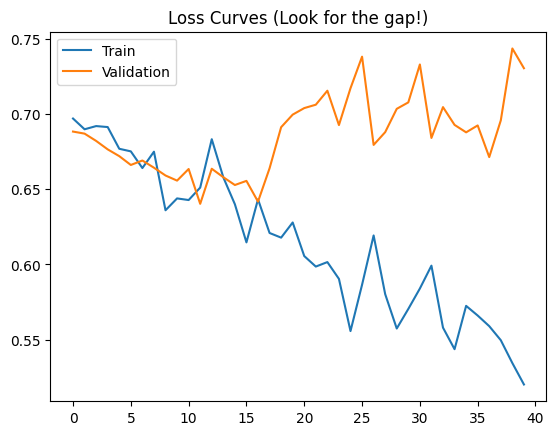

In [104]:
val_freq = 20
n_epochs = 100

model = train_medmnist(model, train_dataloader, val_dataloader, optimizer, epochs=40)

### Τι έχει μάθει το CNN;

Είδαμε παραπάνω τι μπορούν να αναγνωρίσουν συγκεκριμένοι πυρήνες σε μια εικόνα. Αλλά τι έχει βρει ο αλγόριθμος του πυρήνα μας για να ταξινομήσει μεταξύ υγιών και ασθενών πνευμόνων; Παρακάτω, βλέπουμε τους πυρήνες του δεύτερου επιπέδου συνελίξεων. Επειδή το πρώτο επίπεδο έχει ήδη εκτελέσει 16 συνελίξεις, υπάρχουν 16 διαφορετικά επίπεδα πυρήνων στο δεύτερο επίπεδο. Μπορείτε να τα δείτε όλα τροποποιώντας τη μεταβλητή <kbd>input_index</kbd>.

/tmp/ipykernel_29722/984550202.py:9: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


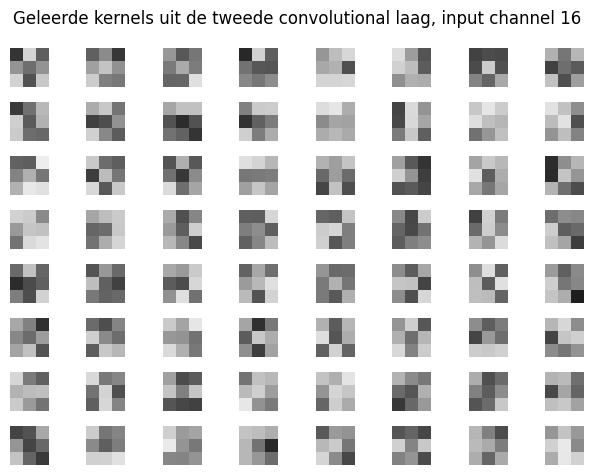

In [105]:
input_index = 16
fig, axs = plt.subplots(8,8, layout='constrained')
for i in range(64):
    kernel = model.conv2.weight[i,input_index,:,:].detach().cpu().numpy()
    cur_ax = np.unravel_index(i, [8,8])
    s = axs[cur_ax].imshow(kernel, clim=[-0.1,0.1],cmap = 'Greys')
    axs[cur_ax].axis('off')
plt.suptitle(f'Geleerde kernels uit de tweede convolutional laag, input channel {input_index}')
plt.tight_layout()
plt.show()

Και εδώ βλέπουμε επίσης τους πυρήνες από το πρώτο στρώμα συνελίξεων.

torch.Size([32, 1, 3, 3])


/tmp/ipykernel_29722/2024605393.py:9: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


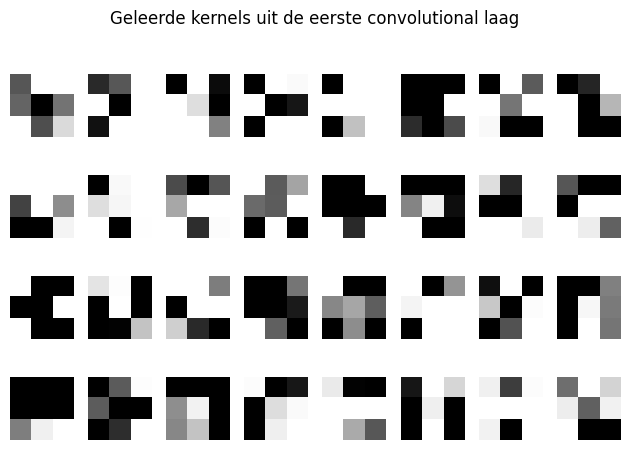

In [106]:
print(np.shape(model.conv1.weight))
fig, axs = plt.subplots(4,8, layout='constrained')
for i in range(32):
    kernel = model.conv1.weight[i,0,:,:].detach().cpu().numpy()
    cur_ax = np.unravel_index(i, [4,8])
    s = axs[cur_ax].imshow(kernel, clim=[-0.1,0.1],cmap = 'Greys')
    axs[cur_ax].axis('off')
plt.suptitle(f'Geleerde kernels uit de eerste convolutional laag')
plt.tight_layout()
plt.show()

## Performance assessment

Τώρα που έχουμε εκπαιδεύσει το μοντέλο, θα εξετάσουμε τον βαθμό στον οποίο μπορεί να κάνει καλές προβλέψεις. Αρχικά, προσδιορίζουμε την ανάκληση και την ακρίβεια του μοντέλου. Η ανάκληση μας λέει πόσα από τα θετικά δεν εντοπίζονται από το μοντέλο (ψευδώς αρνητικά). Η ακρίβεια μετρά πόσα από τα θετικά ταξινομημένα δείγματα είναι στην πραγματικότητα θετικά δείγματα (ψευδώς θετικά). Ποιο μέτρο είναι πιο σημαντικό εξαρτάται από το πρόβλημα. Για παράδειγμα, κατά την ανίχνευση μιας εξαιρετικά σπάνιας μορφής καρκίνου, προτιμάτε μια υψηλή ανάκληση και αποδέχεστε μια χαμηλότερη ακρίβεια ως αποτέλεσμα. Είναι καλύτερο να ανιχνεύετε τα πραγματικά θετικά και να τα χρησιμοποιείτε για να φιλτράρετε τα ψευδώς θετικά σε μια μελέτη παρακολούθησης, αντί να χάνετε εντελώς τα θετικά.

Χρησιμοποιούμε το σύνολο δεδομένων δοκιμής (όχι το σύνολο δεδομένων επικύρωσης) για να προσδιορίσουμε αυτές τις μετρήσεις.

![](https://upload.wikimedia.org/wikipedia/commons/thumb/2/26/Precisionrecall.svg/525px-Precisionrecall.svg.png)

Πριν προσδιορίσουμε αυτές τις μετρήσεις, ας δούμε πρώτα μερικά αποτελέσματα του μοντέλου.


In [107]:
def validation_results_visualize(model, dataset):
    index = np.random.randint(0, len(dataset))
    sample = dataset[index]

    small_image = sample['img']
    label = sample['label']
    orig_img = sample['orig']

    plt.imshow(orig_img, cmap='gray')
    plt.yticks([]); plt.xticks([])

    # convert to tensor
    image_t = torch.tensor(small_image).float().to('cuda') # shape (1,28,28)

    with torch.no_grad():
         output = torch.sigmoid(model(image_t.unsqueeze(0))).item()
         print(index)
         plt.title(f"Πραγματική τιμή: {label}, πιθανότητα απονεύρωσης :{output:.3f}, πρόβλεψη CNN: {int(output >= 0.5)}")
         plt.show()

3


/tmp/ipykernel_29722/2404688601.py:20: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(self.labels[idx])
/tmp/ipykernel_29722/3698399905.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  image_t = torch.tensor(small_image).float().to('cuda') # shape (1,28,28)


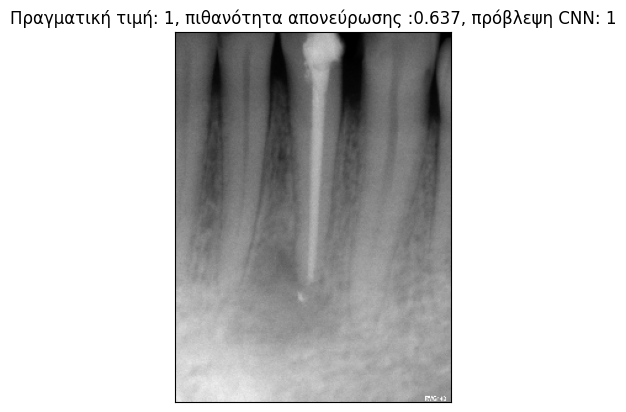

In [108]:
validation_results_visualize(model, test_dataset)

In [ ]:
for i in range(10):
    validation_results_visualize(model, test_dataset)

### Υπολογισμός precision και recall

In [109]:
threshold  = 0.5

def get_precision_recall(model, dataloader):
    model.eval()
    TP, TN, FP, FN = 0, 0, 0, 0

    with torch.no_grad():
         for batch in dataloader:
             images = batch['img'].float().to('cuda') # (B,1,28,28)
             labels = batch['label'].float().to('cuda') # (B,)
             labels = labels.unsqueeze(1) # (B,1)
             outputs = torch.sigmoid(model(images)) # (B,1)
             preds = (outputs >= threshold).float() # (B,1)
             TP += ((preds == 1) & (labels == 1)).sum().item()
             TN += ((preds == 0) & (labels == 0)).sum().item()
             FP += ((preds == 1) & (labels == 0)).sum().item()
             FN += ((preds == 0) & (labels == 1)).sum().item()

    precision = TP / (TP + FP + 1e-8)
    recall = TP / (TP + FN + 1e-8)

    return precision, recall

test_loader = monai.data.DataLoader(test_dataset, batch_size = 32, shuffle=False, collate_fn=collate_without_orig)
precision, recall = get_precision_recall(model, test_loader)
print(f'Το precision του μοντέλου είναι {precision:.2f}, το recall του μοντέλου είναι {recall:.2f}.')

Το precision του μοντέλου είναι 0.68, το recall του μοντέλου είναι 0.74.


/tmp/ipykernel_29722/2404688601.py:20: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(self.labels[idx])


### Ο πίνακας σύγχυσης (confusion matrix)


Παρακάτω μπορείτε να δείτε έναν λεγόμενο «πίνακα σύγχυσης». Πόσες περιπτώσεις απονεύρωσης έχουν παραβλεφθεί; Και πόσο συχνά ένας ασθενής διαγιγνώσκεται λανθασμένα; Τι εικόνα δίνει αυτό για το πόσο ισχυρό είναι το μοντέλο; Μπορείτε επίσης να προσδιορίσετε εάν το μοντέλο λειτουργεί καλά στο σύνολο δεδομένων επικύρωσης;

/tmp/ipykernel_29722/2404688601.py:20: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(self.labels[idx])


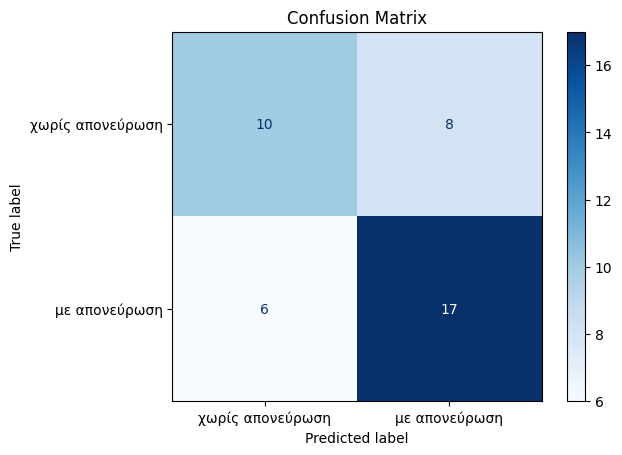

In [110]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_confusion_matrix(model,dataloader):
    """
    Plots a confusion matrix using true and predicted labels.

    :param y_true: List or array of true labels.
    :param y_pred: List or array of predicted labels.
    :param labels: List of label names (optional).
    """
    model.eval()
    true_labels = []
    predicted_labels = []


    for data in dataloader:
        images = data['img'].float().to('cuda')
        labels = data['label'].cpu().numpy()
        with torch.no_grad():
            output = torch.sigmoid(model(images)).cpu().numpy().flatten()
        pred_classes = (output >= threshold).astype(int)
        true_labels.extend(labels)
        predicted_labels.extend(pred_classes)

    cm = confusion_matrix(true_labels, predicted_labels, labels=[0,1])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['χωρίς απονεύρωση', 'με απονεύρωση'])
    disp.plot(cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.show()

plot_confusion_matrix(model, test_loader)

/tmp/ipykernel_29722/2404688601.py:20: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(self.labels[idx])


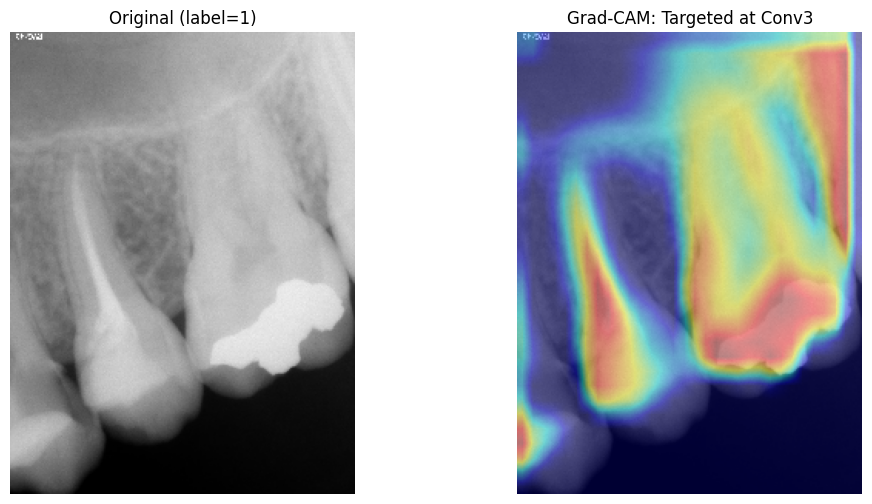

In [115]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.hooks = []

        # Use handles so we can remove them later
        self.hooks.append(self.target_layer.register_forward_hook(self.save_activations))
        self.hooks.append(self.target_layer.register_full_backward_hook(self.save_gradients))

    def save_activations(self, module, input, output):
        self.activations = output.detach()

    def save_gradients(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor):
        output = self.model(input_tensor)
        self.model.zero_grad()
        output.backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1).squeeze()
        cam = np.maximum(cam.cpu().numpy(), 0)

        if cam.max() > 0:
            cam = cam / cam.max()

        # IMPORTANT: Remove hooks after generating to prevent the error
        for hook in self.hooks:
            hook.remove()

        return cam

def visualize_gradcam(model, dataset, index, device='cuda'):
    model.eval()
    sample = dataset[index]

    # Process image for model
    small_img = sample['img'].unsqueeze(0).float().to(device)
    orig_img = sample['orig']
    label = sample['label']

    # --- CHANGE THIS LINE ---
    # Point to model.conv3 instead of model.conv2
    gradcam = GradCAM(model, model.conv3)
    # ------------------------

    cam = gradcam.generate(small_img)

    # Ensure orig_img is in 0-255 range and uint8 for OpenCV
    if orig_img.max() <= 1.0:
        display_img = (orig_img * 255).astype(np.uint8)
    else:
        display_img = orig_img.astype(np.uint8)

    # Resize CAM to match original image size
    cam_resized = cv2.resize(cam, (display_img.shape[1], display_img.shape[0]))

    # Create Heatmap
    heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    # Overlay
    # We convert display_img to 3 channels to match the heatmap
    background = np.stack([display_img]*3, axis=-1)
    overlay = 0.4 * heatmap + 0.6 * background
    overlay = np.clip(overlay, 0, 255).astype(np.uint8)

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(display_img, cmap='gray')
    plt.title(f"Original (label={label})")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(overlay)
    plt.title("Grad-CAM: Targeted at Conv3")
    plt.axis('off')
    plt.show()

# Run it on a known positive image
visualize_gradcam(model, test_dataset, index=12)
